In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [72]:
df = pd.read_csv('Customer Churn.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#replacing TotalCharges blanks by 0 as tenure is 0. no TotalCharges are recorded

In [29]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"]= df["TotalCharges"].astype('float')


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [31]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [32]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [33]:
df.duplicated().sum()

0

#Converted SeniorCitizen Boolean values to Yes/No

In [73]:
def conv(value):
    if value == 0:
        return "no"
    else:
        return "yes"
        
df["SeniorCitizen"] = df["SeniorCitizen"].apply(conv)

In [85]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Churn analysis

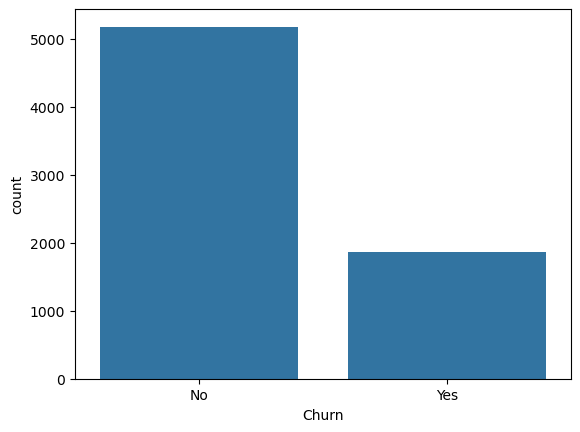

In [75]:
sns.countplot(x=df["Churn"], data = df)
plt.show()

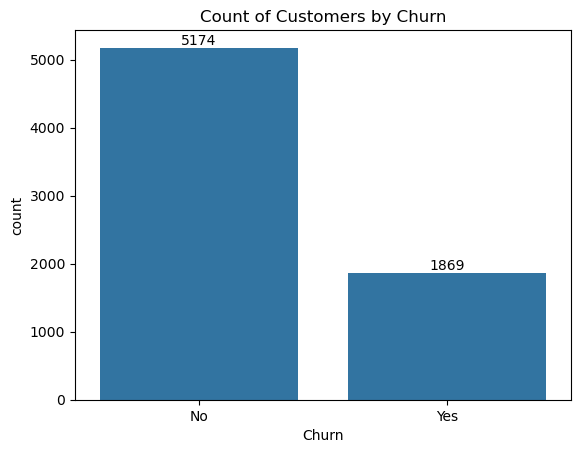

In [76]:
ax=sns.countplot(x=df["Churn"], data = df)
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Churn")
plt.show()


# From the pie chart analysis, we can observe 26.54% of customers have churned out

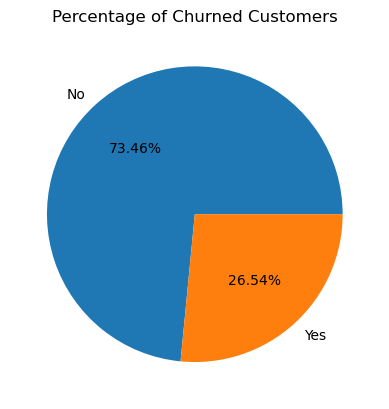

In [77]:
gb = df.groupby("Churn").agg({'Churn':'count'})
plt.pie(gb['Churn'],labels = gb.index, autopct = "%1.2f%%")
plt.title("Percentage of Churned Customers")
plt.show()

# From the below analysis, we can observe Churn out is equal in male and female

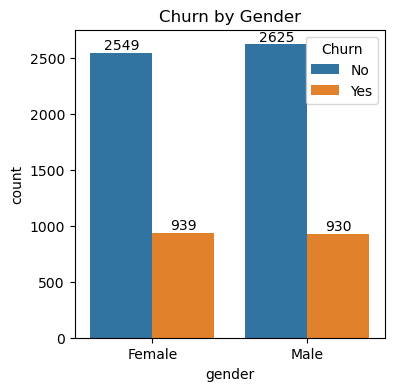

In [83]:
plt.figure( figsize = (4,4))
ax = sns.countplot(x = 'gender', data= df ,hue='Churn')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Churn by Gender')
plt.show()


# Churn out by Senior Citizen, compartively churn out  is observed more in senior citizen

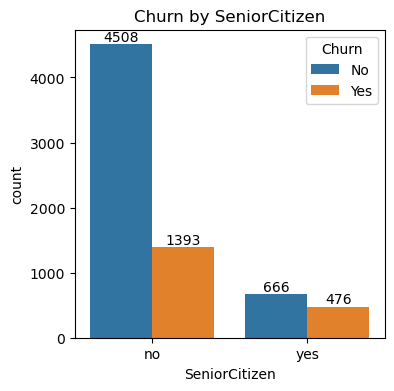

In [84]:
plt.figure( figsize = (4,4))
ax=sns.countplot(x = 'SeniorCitizen', data= df ,hue='Churn')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Churn by SeniorCitizen')
plt.show()


# people who have used our services for long have stayed and people who who have used our services for short time have churned out

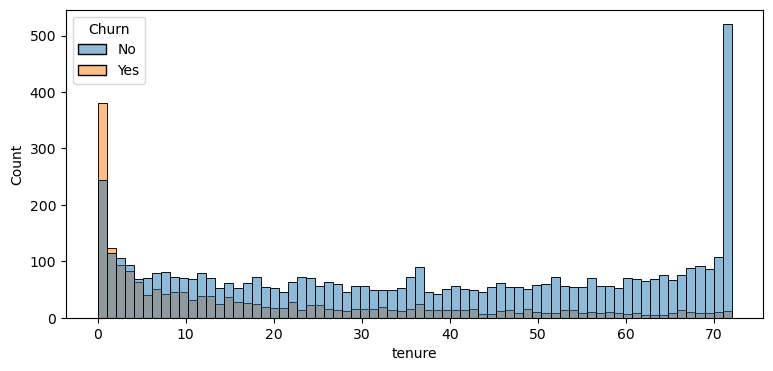

In [91]:
plt.figure(figsize = (9,4))
sns.histplot(x='tenure', data=df, bins = 70, hue = 'Churn')
plt.show()

# people who have month-to-month contract are likely to Churn then from those who have 1-2 year contract

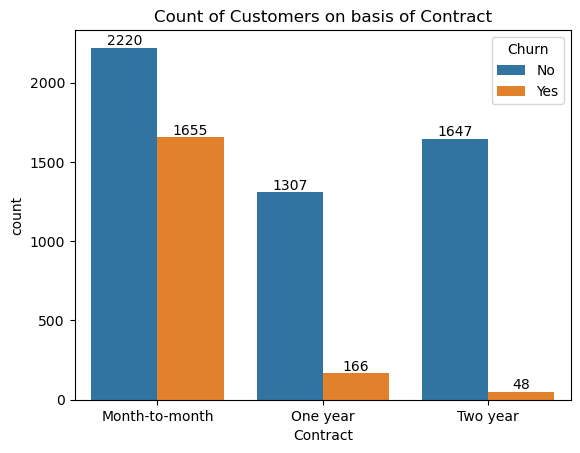

In [95]:
ax=sns.countplot(x=df["Contract"], data = df, hue = 'Churn')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Count of Customers on basis of Contract")
plt.show()

# Customers with Fiber Optic internet and no Tech Support show significantly higher churn, while those with DSL and active Tech Support are more likely to be retained, and customers with no internet service have the lowest churn overall.

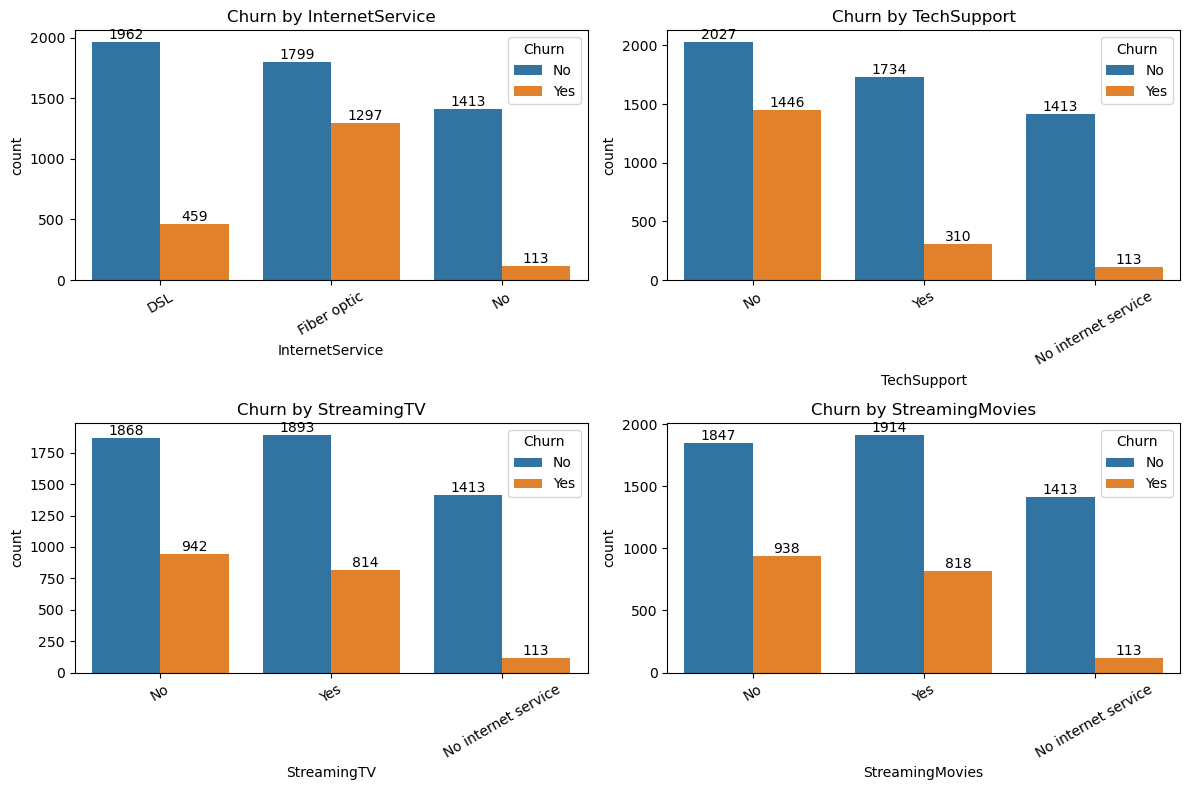

In [97]:
cols = ['InternetService', 'TechSupport', 
        'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, col in enumerate(cols):
    row = i // 2
    col_pos = i % 2
    
    ax = sns.countplot(data=df, x=col, hue='Churn', ax=axes[row, col_pos])
    axes[row, col_pos].set_title(f'Churn by {col}')
    axes[row, col_pos].tick_params(axis='x', rotation=30)
    for container in ax.containers:
        ax.bar_label(container)

plt.tight_layout()
plt.show()

# Churn is observed more when payment method is Electronic Check

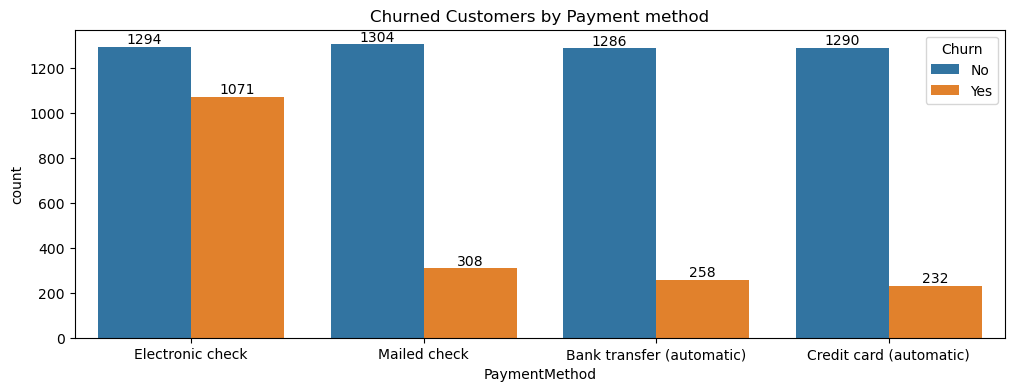

In [100]:
plt.figure(figsize = (12,4))
ax=sns.countplot(x=df["PaymentMethod"], data = df, hue = 'Churn')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Churned Customers by Payment method")
plt.show()